
# Lithium atomic beam: transverse cooling + optional 2D MOT + downstream orifice optimization

This notebook adds:

**(i)** Side-view schematic plots (x vs z) with representative trajectories for three cases:
1. No cooling, no 2D MOT
2. Transverse cooling in mirror region only
3. Transverse cooling + optimized 2D MOT just behind the mirrors

**(ii)** Prints the **optimized 2D MOT parameters** (length + spring/damping) and the achieved gain in flux through the downstream orifice.

## Notes
- Physics is a **fast design-level model** (two-level Doppler molasses in the mirror region, and a linear spring+damping model for the 2D MOT).
- The 2D MOT model captures the “focusing + damping” effect:
  \[ \mathbf F_\perp = -\kappa \mathbf r_\perp - \beta \mathbf v_\perp. \]
- The downstream orifice is a **1 cm diameter** aperture located **50 cm after the mirror end**, as requested.

- Updated propagation now uses each atom's own longitudinal velocity through the mirror and 2D-MOT regions, fixes the downstream drift geometry, and records several intermediate trajectory points so the side-view is more physical.


In [1]:
# Enable automatic reloading of modules so that changes in external Python files are reflected without restarting the notebook
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from dataclasses import dataclass, replace
from scipy.constants import k as k_B, h, c, atomic_mass
from scipy.special import erf
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
import li6_cooling_opt_functions as cool
import ipywidgets as widgets
import warnings
from skopt import gp_minimize
from skopt.space import Real
from functools import partial

rng = np.random.default_rng(12345)

# ---------------- Physical constants ----------------
h = 6.62607015e-34
hbar = h/(2*np.pi)
kB = 1.380649e-23
amu = 1.66053906660e-27

print("Imports and constants loaded.")

Imports and constants loaded.


In [3]:
%matplotlib widget


## User parameters (edit here)


In [4]:
# cfg = cool.SourceConfig(tube_length=0.1, tube_radius=0.007/2)
cfg = cool.SourceConfig(dt=1e-6)
print(f"SourceConfig created: {cfg}")

SourceConfig created: SourceConfig(N_atoms=5000000, isotope='Li-6', mass=9.988142485598999e-27, lambda0=6.70977e-07, k=9364233.50901683, Gamma=36882297.753144175, Isat_mW_cm2=2.54, Isat=25.4, T_oven_C=600.0, T_oven_K=873.15, oven_channel_radius=0.02, tube_length=0.09453, tube_radius=0.001808, beta_mot=0.0, kappa_mot=0.0, B_grad=0.0, mu_eff=9.274e-24, Px_mW_mot=80.0, Py_mW_mot=80.0, w_mm_mot=6.0, N_bounce_x=6, N_bounce_y=6, Rpass_x=0.9, Rpass_y=0.9, Px_mW=80.0, Py_mW=80.0, w_mm=6.0, delta_over_Gamma=-1.0, z_cooling_start=0.02, z_cooling_end=0.22, z_mot_start=0.221, z_mot_end=0.28, z_orifice=3.0, orifice_radius=0.005, use_skimmer=False, skimmer_radius=0.005, dt=1e-06, include_diffusion=True, include_mot_diffusion=True, alpha_diff=0.5)



## Effusive flux estimate (order-of-magnitude)


In [5]:
Ndot_hole, P_oven, n_oven, vbar, A_hole = cool.effusive_flux_atoms_per_s(cfg.T_oven_K, cfg.mass, cfg.oven_channel_radius*2)
print(f"Vapor pressure ~ {P_oven:.3g} Pa, mean speed ~ {vbar:.1f} m/s")
print(f"Flux through the oven channel (prior to tube exit) ~ {Ndot_hole:.3e} atoms/s")

Vapor pressure ~ 6.59 Pa, mean speed ~ 1753.1 m/s
Flux through the oven channel (prior to tube exit) ~ 3.011e+20 atoms/s



## Mirror-pass gain and Doppler molasses model


In [6]:
# Effective saturation inside mirror region
w_m = cfg.w_mm*1e-3
I0x = cool.gaussian_I0(cfg.Px_mW*1e-3, w_m)
I0y = cool.gaussian_I0(cfg.Py_mW*1e-3, w_m)
s0x = I0x/cfg.Isat
s0y = I0y/cfg.Isat

Gx = cool.gain_geometric(cfg.N_bounce_x, cfg.Rpass_x)
Gy = cool.gain_geometric(cfg.N_bounce_y, cfg.Rpass_y)

s0x_eff = Gx*s0x
s0y_eff = Gy*s0y

print(f"Gx={Gx:.2f}, Gy={Gy:.2f}")
print(f"s0x_eff={s0x_eff:.2f}, s0y_eff={s0y_eff:.2f}")


Gx=4.69, Gy=4.69
s0x_eff=260.97, s0y_eff=260.97



## Efficient effusive sampling with optional skimmer at z_start


Sampled atoms: 1833
Transmission frequency: 0.036660000000000005 %
Mean vz: 2064.6409642577087
Mean transverse speed: 35.486407756860096
Oven consumption rate: 4.253e-01 grams/day
Oven consumption rate: 1.772e-02 grams/hour
Oven consumption rate: 1.553e+02 grams/year


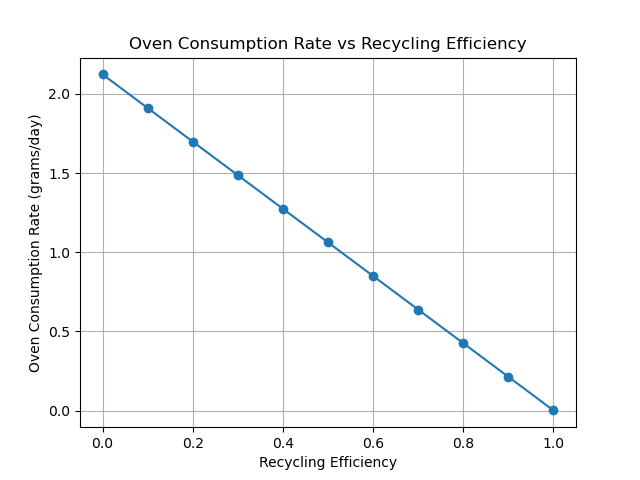

In [7]:
# This creates the distribution of atoms exiting the tube, including their positions and velocities, to use in the cooling and MOT sims
beam_exiting_tube = cool.sample_effusive_beam(cfg)
print("Sampled atoms:", len(beam_exiting_tube["x"]))
print("Transmission frequency:", len(beam_exiting_tube["x"])/cfg.N_atoms * 100, "%")
print("Mean vz:", beam_exiting_tube["vz"].mean())
print("Mean transverse speed:", np.sqrt(beam_exiting_tube["vx"]**2 + beam_exiting_tube["vy"]**2).mean())

# Calculate the oven consumption
consumption_rates = cool.oven_consumption_rate(beam_exiting_tube, cfg, recycling_efficiency=0.8)
print(f"Oven consumption rate: {consumption_rates['consumption_rate_grams_per_day']:.3e} grams/day")
print(f"Oven consumption rate: {consumption_rates['consumption_rate_grams_per_hour']:.3e} grams/hour")
print(f"Oven consumption rate: {consumption_rates['consumption_rate_grams_per_year']:.3e} grams/year")

recycling_efficiencies = np.linspace(0, 1, 11)
cool.plot_consumptions(beam_exiting_tube, cfg, recycling_efficiencies=recycling_efficiencies)

## Model update notes

This version fixes three important issues in the original propagation:

1. Each atom now spends its **own** time in the mirror and 2D-MOT regions according to its own \(v_z\), rather than using the time of a very slow atom for everyone.
2. The drift to the downstream orifice now starts from the **actual end of the MOT section**.
3. The trajectory plot stores several intermediate points inside the mirror and MOT regions, so the side-view is no longer just a few straight segments between section boundaries.

The 2D MOT itself is still a **toy spring+damping model**,
\[
F_x=-\kappa x-eta v_x,\qquad F_y=-\kappa y-eta v_y,
\]
so the notebook should still be interpreted as a fast design study rather than a full lithium MOT simulation.

In [41]:
df_scan, best = cool.optimize_2dmot_with_beam(beam_exiting_tube, cfg)
best

{'L_mot_cm': 15.0,
 'beta': 5e-23,
 'kappa': 2e-19,
 'frac_pass': np.float64(0.40175631174533477),
 'Ndot_orifice': np.float64(732.0),
 'orifice_flux': np.float64(360215149220420.6)}

In [42]:
df_scan.sort_values("Ndot_orifice", ascending=False).head(10)

,L_mot_cm,beta,kappa,frac_pass,Ndot_orifice,orifice_flux
247,15.0,5.000000e-23,2.000000e-19,0.401756,732.0,3.602151e+14
211,12.5,5.000000e-23,2.000000e-19,0.384193,700.0,3.444680e+14
175,10.0,5.000000e-23,2.000000e-19,0.370472,675.0,3.321656e+14
246,15.0,5.000000e-23,0.000000e+00,0.350714,639.0,3.144501e+14
210,12.5,5.000000e-23,0.000000e+00,0.334248,609.0,2.996872e+14
139,7.5,5.000000e-23,2.000000e-19,0.330406,602.0,2.962425e+14
241,15.0,2.000000e-23,2.000000e-19,0.318332,580.0,2.854164e+14
205,12.5,2.000000e-23,2.000000e-19,0.317234,578.0,2.844322e+14
174,10.0,5.000000e-23,0.000000e+00,0.306257,558.0,2.745902e+14
103,5.0,5.000000e-23,2.000000e-19,0.302964,552.0,2.716377e+14


### Trajectory-plot fix
The side-view snapshots now interpolate each selected atom to common z-planes. This removes the old plotting artifact that could make straight drifts appear to bend or focus.



## Run three cases and plot side-view trajectories


In [43]:
# --- run the three configurations ---
n_traj = 200

# Case 1: no cooling, no 2D MOT
case1 = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, beta_mot=0.0, kappa_mot=0.0),
    use_mot=False,
    mirror_cooling=False,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 2: mirror cooling only, no 2D MOT
case2 = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, beta_mot=0.0, kappa_mot=0.0),
    use_mot=False,
    mirror_cooling=True,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 3: mirror cooling + 2D MOT
case3 = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, beta_mot=best["beta"], kappa_mot=best["kappa"]),
    use_mot=True,
    mirror_cooling=True,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

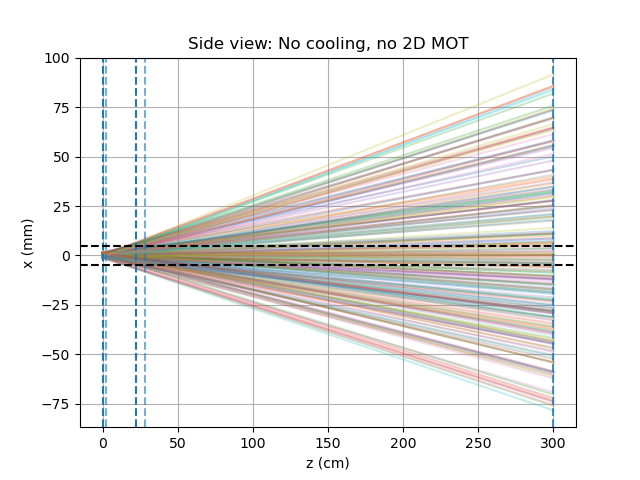

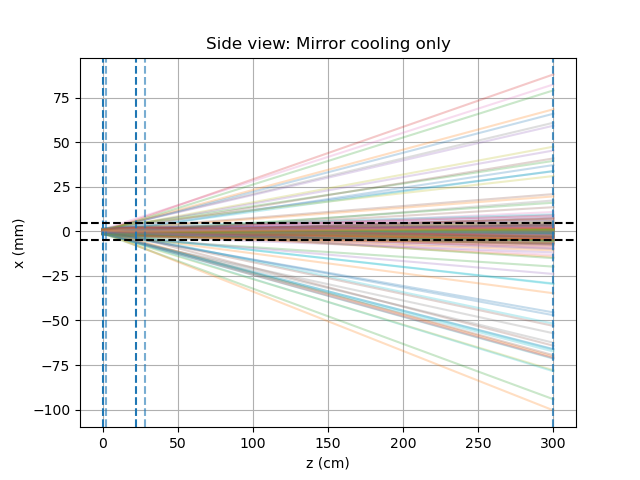

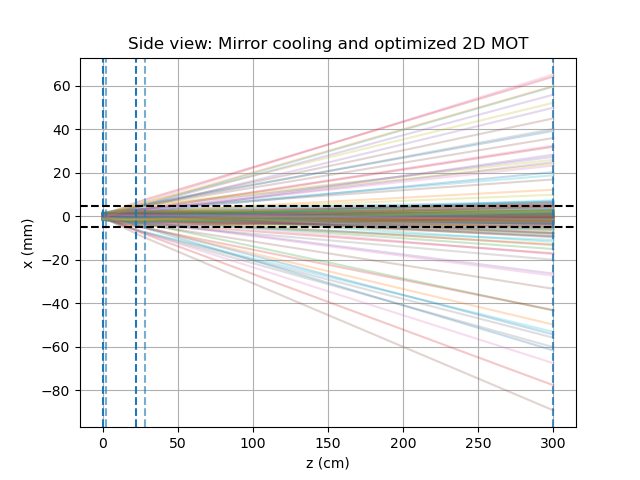

In [44]:
cases = ["No cooling, no 2D MOT", "Mirror cooling only", "Mirror cooling and optimized 2D MOT"]
for i in range(3):
    cool.plot_sideview(eval(f"case{i+1}"), cfg, f"Side view: {cases[i]}")


In [45]:
df_scan_full, best_full = cool.optimize_full_2dmot_with_beam(beam_exiting_tube, cfg)
best_full

{'L_mot_cm': 15.0,
 'B_grad': 0.05,
 'frac_pass': np.float64(0.6646542261251372),
 'Ndot_orifice': np.float64(1211.0),
 'orifice_flux': np.float64(595929707248537.4)}

In [46]:
df_scan_full.sort_values("Ndot_orifice", ascending=False).head(10)

,L_mot_cm,B_grad,frac_pass,Ndot_orifice,orifice_flux
44,15.0,0.05,0.664654,1211.0,5.959297e+14
45,15.0,0.07,0.653677,1191.0,5.860878e+14
43,15.0,0.03,0.649286,1183.0,5.821510e+14
37,12.5,0.05,0.646542,1178.0,5.796905e+14
36,12.5,0.03,0.641054,1168.0,5.747695e+14
30,10.0,0.05,0.639407,1165.0,5.732932e+14
29,10.0,0.03,0.638310,1163.0,5.723090e+14
38,12.5,0.07,0.637212,1161.0,5.713248e+14
46,15.0,0.10,0.633919,1155.0,5.683723e+14
31,10.0,0.07,0.630626,1149.0,5.654197e+14


In [47]:
# --- run the three configurations ---
n_traj = 200

# Case 1: no cooling, no 2D MOT
case1_full = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg),
    use_mot=False,
    mirror_cooling=False,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 2: mirror cooling only, no 2D MOT
case2_full = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg),
    use_mot=False,
    mirror_cooling=True,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 3: mirror cooling + 2D MOT
case3_full = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, z_mot_end = cfg.z_mot_start + best_full["L_mot_cm"]*1e-2, B_grad=best_full["B_grad"]),
    use_mot=True,
    mirror_cooling=True,
    mot_mode='mot_full',
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

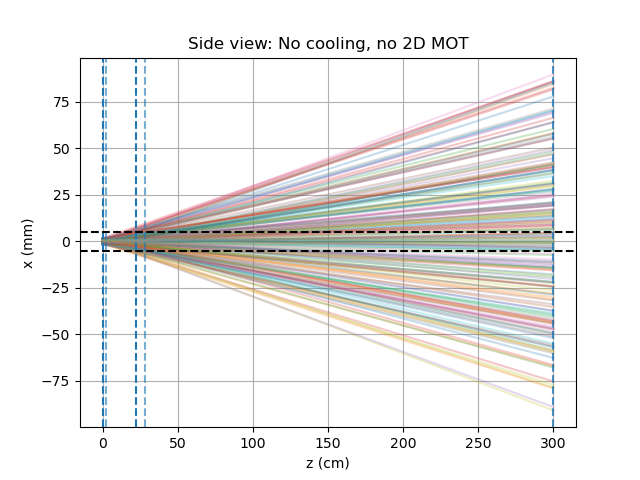

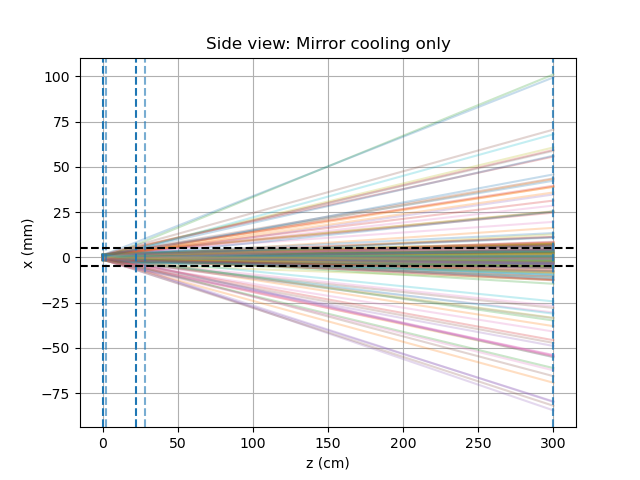

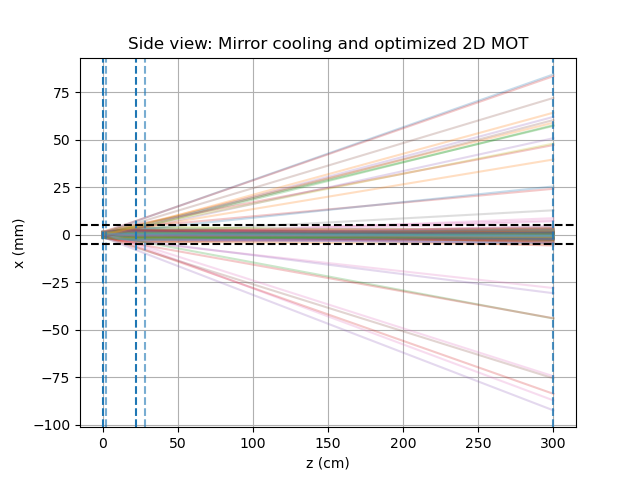

In [48]:
cases = ["No cooling, no 2D MOT", "Mirror cooling only", "Mirror cooling and optimized 2D MOT"]
for i in range(3):
    cool.plot_sideview(eval(f"case{i+1}_full"), cfg, f"Side view: {cases[i]}")

## Using SciKit optimize to find best MOT length, B_field, and laser powers.

In [49]:
mot_search_space = [
    Real(1.0, 15.0, name='mot_length_cm'),
    Real(0.01, 0.2, name='B_grad'),
    Real(40.0, 120.0, name='Px_mw'),
    Real(40.0, 120.0, name='Py_mw'),
    Real(3.0, 9.0, name='w_mm')
]

cfg_local = replace(cfg)

objective = partial(
    cool.objective,
    beam=beam_exiting_tube,
    cfg_base=cfg_local,
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", message=".*ConvergenceWarning.*")
    with np.errstate(all="ignore"):
        res = gp_minimize(
            objective,
            dimensions=mot_search_space,
            acq_func='EI',
            n_calls=100,
            random_state=42
        )

best_length_cm, best_grad, best_Px_mw, best_Py_mw, best_w_mm = res.x
best_flux = res.fun

c:\Users\dusty\miniconda3\envs\Li6Beam\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [15.0, 0.01, 40.0, 40.0, 9.0] before, using random point [1.8405022529442012, 0.1016484928729056, 74.10923452885604, 57.091050170235626, 8.327929762641958]
  warnings.warn(
c:\Users\dusty\miniconda3\envs\Li6Beam\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [15.0, 0.01, 40.0, 40.0, 9.0] before, using random point [10.996974213861595, 0.030380040446849117, 111.6270451164094, 104.26820712163453, 8.438681451958]
  warnings.warn(
c:\Users\dusty\miniconda3\envs\Li6Beam\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [15.0, 0.01, 40.0, 40.0, 9.0] before, using random point [9.852742491206383, 0.17614378320876123, 70.21329542991008, 93.41099589530282, 8.957090684615512]
  warnings.warn(
c:\Users\dusty\miniconda3\envs\Li6Beam\Lib\si

In [53]:
print(f"Best parameters: L_mot={best_length_cm:.2f} cm, "
      f"B_grad={best_grad:.3f} T/m, "
      f"Px_mw={best_Px_mw:.1f} mW, "
      f"Py_mw={best_Py_mw:.1f} mW, "
      f"w_mm={best_w_mm:.2f} mm")

print(f"Best flux at orifice: {-best_flux:.3e} atoms/s")

Best parameters: L_mot=15.00 cm, B_grad=0.056 T/m, Px_mw=40.0 mW, Py_mw=40.0 mW, w_mm=9.00 mm
Best flux at orifice: 6.205e+14 atoms/s


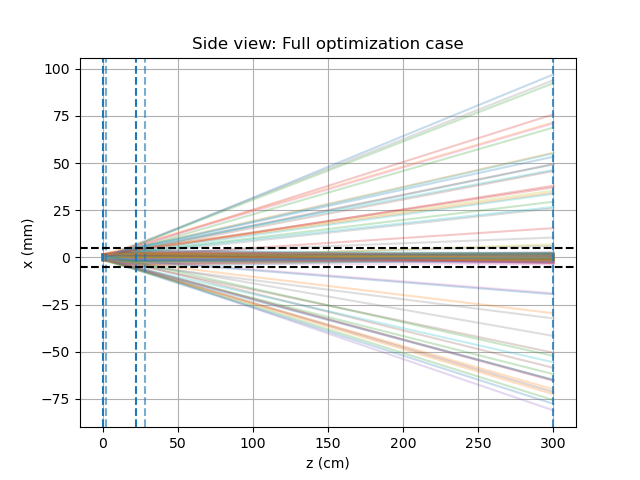

In [54]:
# Rerunning to optimized parameters
n_traj = 200

full_opt_case = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, z_mot_end = cfg.z_mot_start + best_length_cm*1e-2, B_grad=best_grad,
        Px_mW_mot=best_Px_mw, Py_mW_mot=best_Py_mw),
    use_mot=True,
    mirror_cooling=True,
    mot_mode='mot_full',
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

cool.plot_sideview(full_opt_case, cfg, "Side view: Full optimization case")


## Print optimized 2D MOT dimensions/parameters (requested)


In [52]:
# --- compute gains ---

gain_cooling = case2["Ndot_orifice"] / case1["Ndot_orifice"]
gain_bestmot = case3["Ndot_orifice"] / case2["Ndot_orifice"]
gain_total   = case3["Ndot_orifice"] / case1["Ndot_orifice"]

print("---- Achieved fluxes ----")
print(f"No cooling/no MOT flux      : {case1['Ndot_orifice']:.3e} atoms/s")
print(f"Cooling only flux           : {case2['Ndot_orifice']:.3e} atoms/s  (gain {gain_cooling:.3f}×)")
print(f"Cooling + best 2D MOT flux  : {case3['Ndot_orifice']:.3e} atoms/s  (gain vs cooling {gain_bestmot:.3f}×, total {gain_total:.3f}×)")
print("==== OPTIMIZED 2D MOT DESIGN (coarse scan) ====")
print(f"L_mot_cm  = {best['L_mot_cm']}")
print(f"beta_mot  = {best['beta']:.3e}  kg/s")
print(f"kappa_mot = {best['kappa']:.3e} N/m")
print("---- Achieved fluxes ----")
print(f"No cooling/no MOT flux      : {case1['Ndot_orifice']:.3e} atoms/s")
print(f"Cooling only flux           : {case2['Ndot_orifice']:.3e} atoms/s  (gain {gain_cooling:.3f}×)")
print(f"Cooling + best 2D MOT flux  : {case3['Ndot_orifice']:.3e} atoms/s  (gain vs cooling {gain_bestmot:.3f}×, total {gain_total:.3f}×)")


---- Achieved fluxes ----
No cooling/no MOT flux      : 1.600e+01 atoms/s
Cooling only flux           : 3.930e+02 atoms/s  (gain 24.562×)
Cooling + best 2D MOT flux  : 6.310e+02 atoms/s  (gain vs cooling 1.606×, total 39.438×)
==== OPTIMIZED 2D MOT DESIGN (coarse scan) ====
L_mot_cm  = 15.0
beta_mot  = 5.000e-23  kg/s
kappa_mot = 2.000e-19 N/m
---- Achieved fluxes ----
No cooling/no MOT flux      : 1.600e+01 atoms/s
Cooling only flux           : 3.930e+02 atoms/s  (gain 24.562×)
Cooling + best 2D MOT flux  : 6.310e+02 atoms/s  (gain vs cooling 1.606×, total 39.438×)
